# Model lab – Atmosphere Exercise

## AR5 to AR6 difference: GMST→GSAT

## Q1: How different are surface temperature and surface air temperature in CMIP6 historical experiment?

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# for catalog
import intake
import intake_esm

import gcsfs

%matplotlib inline

### Find the right variables for analysis: GMST - global mean surface temperature; GSAT - global surface air temperature. Choose a model to analyse.

<details>
    <summary>Hint</summary>
You can look it up <a href="https://clipc-services.ceda.ac.uk/dreq/index/var.html">here</a> or in <a href="https://github.com/PCMDI/cmip6-cmor-tables">CMOR-tables</a> or  <a href="https://clipc-services.ceda.ac.uk/dreq/mipVars.html">MPI-variables</a>
</details>

tas,
ts

### Choose climatology period (1961-1990) and read the data

In [2]:
datafile1 = xr.open_dataset("~/shared-tacco-ns1004k-cmip-betzy/NCAR/CESM2/historical/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc")
datafile1

/opt/conda/envs/labs/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    tas        (time, lat, lon) float32 438MB ...
    time_bnds  (time, nbnd) object 32kB ...
    lat_bnds   (lat, nbnd) float32 2kB ...
    lon_bnds   (lon, nbnd) float32 2kB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T23:34:05Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [3]:
datafile2 = xr.open_dataset("~/shared-tacco-ns1004k-cmip-betzy/NCAR/CESM2/historical/r1i1p1f1/Amon/ts/gn/latest/ts_Amon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc")
datafile2

/opt/conda/envs/labs/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'ts' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 438MB
Dimensions:    (time: 1980, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Dimensions without coordinates: nbnd
Data variables:
    ts         (time, lat, lon) float32 438MB ...
    time_bnds  (time, nbnd) object 32kB ...
    lat_bnds   (lat, nbnd) float32 2kB ...
    lon_bnds   (lon, nbnd) float32 2kB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T21:40:35Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [4]:
tas =  datafile1['tas']
ts = datafile2['ts']


### Calculate weighted mean

We use the temperature dataset. This dataset has a regular latitude/ longitude grid, thus the grid cell area decreases towards the pole. This means just averaging over the model output would give each gridcell the same weight, which is not the spatial average. For this grid we can use the cosine of the latitude as proxy for the grid cell area.

<details>
    <summary>Hint</summary>
You can look it up in <a href="https://docs.xarray.dev/en/latest/examples/area_weighted_temperature.html">xarray docs f.e.</a>
</details>

In [5]:
# calculate weights, are the same for both outputs as they live on the same grid
weights = np.cos(np.deg2rad(tas.lat))

In [6]:
# calculate weighted tas mean (GSAT)
tas_w = tas.weighted(weights) 
tas_w_sm = tas_w.mean(("lon", "lat"))

# calculate weighted ts mean (GMST)
ts_w = ts.weighted(weights) 
ts_w_sm = ts_w.mean(("lon", "lat"))

In [7]:
# calculate baseline GSAT AND GST (temporal mean for the climatological period used as baseline)
GSAT_baseline = tas_w_sm.sel(time=slice('1961','1990')).mean()
GMST_baseline = ts_w_sm.sel(time=slice('1961','1990')).mean()

### Plot timeseries of GSAT and GMST and difference between them, as well as the anomalies of GSAT and GMST 

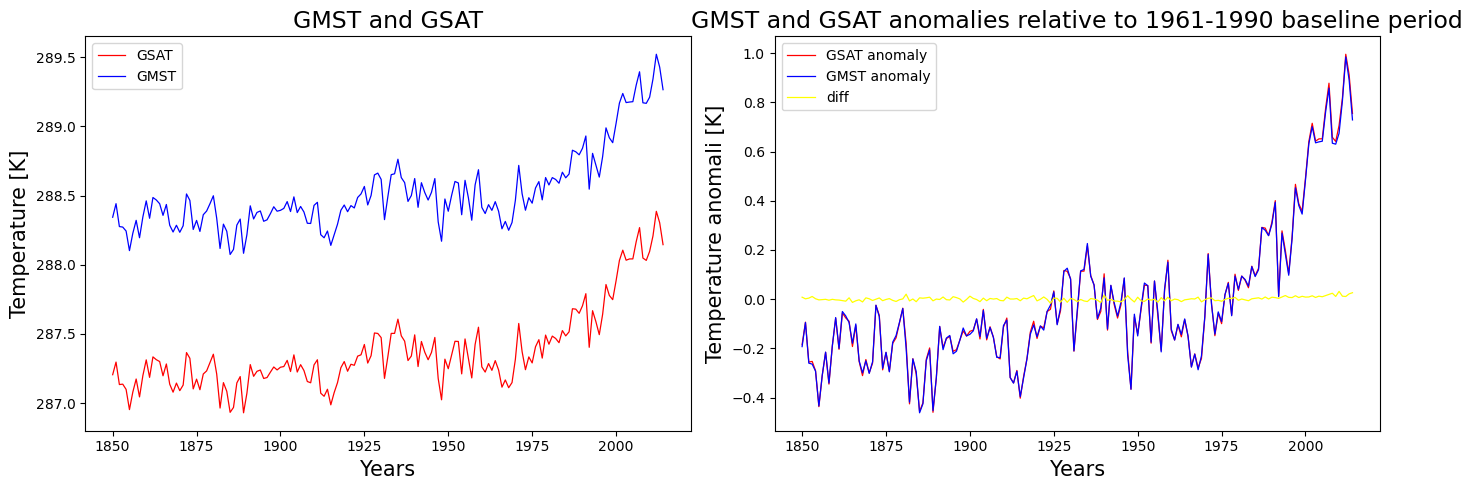

In [8]:
fig, (axs) = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

GSAT = tas_w_sm.groupby('time.year').mean('time')
GSAT.plot(ax=axs[0], linewidth = 0.9, color='red', label='GSAT')
GMST = ts_w_sm.groupby('time.year').mean('time')
GMST.plot(ax=axs[0], linewidth = 0.9, color='blue', label='GMST')

GSAT_anomaly = (tas_w_sm - GSAT_baseline).groupby('time.year').mean('time')
GSAT_anomaly.plot(ax=axs[1], linewidth = 0.9, color='red', label='GSAT anomaly')
GMST_anomaly = (ts_w_sm - GMST_baseline).groupby('time.year').mean('time')
GMST_anomaly.plot(ax=axs[1], linewidth = 0.9, color='blue', label='GMST anomaly')
diff_GSAT_GMST = ( (tas_w_sm - GSAT_baseline).groupby('time.year').mean('time')-(ts_w_sm - GMST_baseline).groupby('time.year').mean('time') ).plot(ax=axs[1], linewidth = 0.9, color='yellow', label='diff')

axs[0].set_ylabel('Temperature [K]', fontsize=15)
axs[0].set_xlabel('Years', fontsize=15)
axs[1].set_xlabel('Years', fontsize=15)
axs[1].set_ylabel('Temperature anomali [K]', fontsize=15)
axs[0].set_title('GMST and GSAT', fontsize=17)
axs[1].set_title('GMST and GSAT anomalies relative to 1961-1990 baseline period', fontsize=17)
axs[0].legend()
axs[1].legend()
plt.tight_layout()

### Show a spatial pattern of the difference between tas and ts

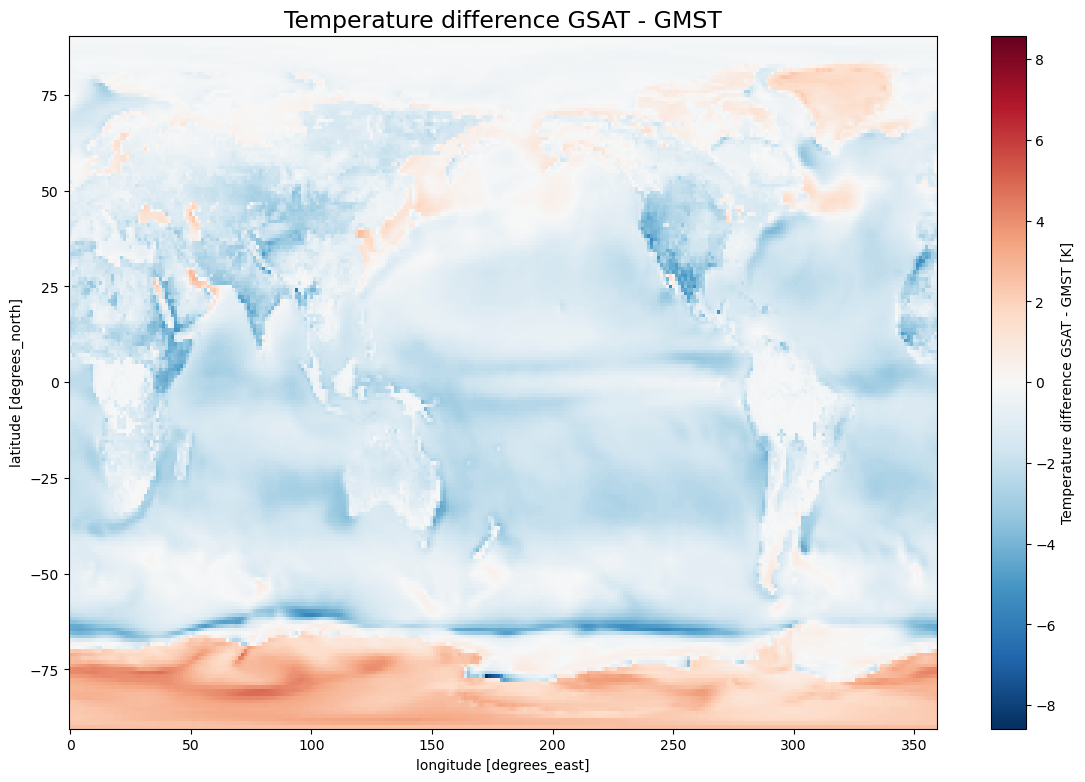

In [10]:
fig, ax = plt.subplots( figsize=(14,9))
diff = (datafile1['tas'] - datafile2['ts']).isel(time=40) # just as an example, this is not for min / max years

plot = diff.plot()

ax.set_title('Temperature difference GSAT - GMST', fontsize=17)
plot.colorbar.set_label('Temperature difference GSAT - GMST [K]')

### Q2: How does a different climatology affect the above temperature differences?
Use the climatology periods 1986-2005 and 1995-2014.

In [11]:
# calculate baseline GSAT AND GST (temporal mean for the climatological period used as baseline)
GSAT_baseline = tas_w_sm.sel(time=slice('1986','2005')).mean()
GMST_baseline = ts_w_sm.sel(time=slice('1986','2005')).mean()

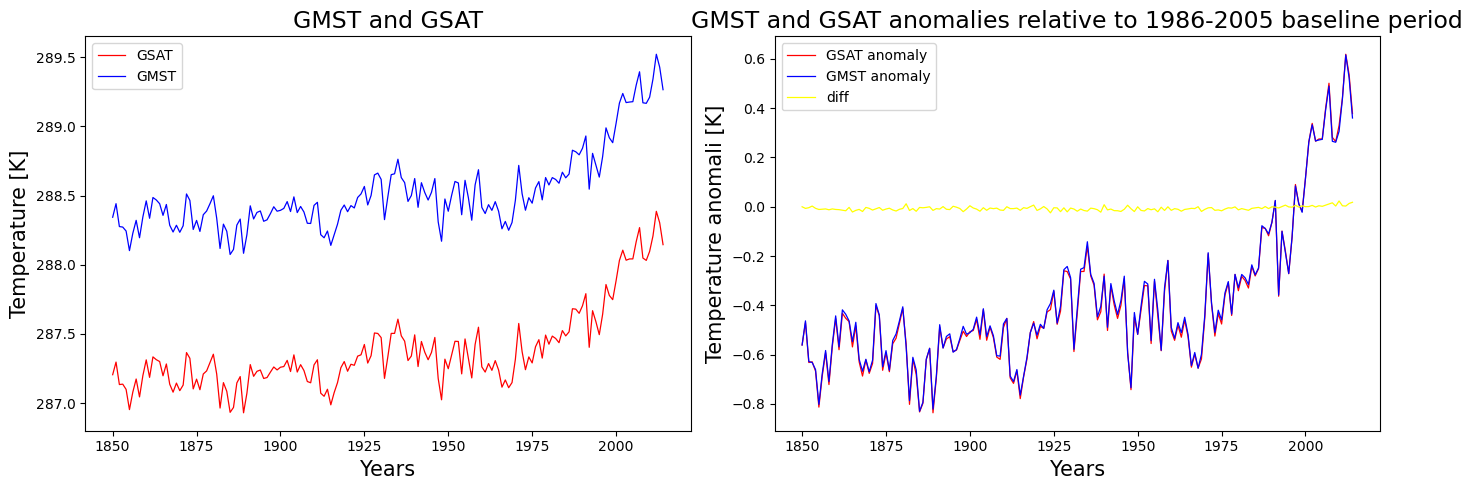

In [12]:
fig, (axs) = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

GSAT = tas_w_sm.groupby('time.year').mean('time')
GSAT.plot(ax=axs[0], linewidth = 0.9, color='red', label='GSAT')
GMST = ts_w_sm.groupby('time.year').mean('time')
GMST.plot(ax=axs[0], linewidth = 0.9, color='blue', label='GMST')

GSAT_anomaly = (tas_w_sm - GSAT_baseline).groupby('time.year').mean('time')
GSAT_anomaly.plot(ax=axs[1], linewidth = 0.9, color='red', label='GSAT anomaly')
GMST_anomaly = (ts_w_sm - GMST_baseline).groupby('time.year').mean('time')
GMST_anomaly.plot(ax=axs[1], linewidth = 0.9, color='blue', label='GMST anomaly')
diff_GSAT_GMST = ( (tas_w_sm - GSAT_baseline).groupby('time.year').mean('time')-(ts_w_sm - GMST_baseline).groupby('time.year').mean('time') ).plot(ax=axs[1], linewidth = 0.9, color='yellow', label='diff')

axs[0].set_ylabel('Temperature [K]', fontsize=15)
axs[0].set_xlabel('Years', fontsize=15)
axs[1].set_xlabel('Years', fontsize=15)
axs[1].set_ylabel('Temperature anomali [K]', fontsize=15)
axs[0].set_title('GMST and GSAT', fontsize=17)
axs[1].set_title('GMST and GSAT anomalies relative to 1986-2005 baseline period', fontsize=17)
axs[0].legend()
axs[1].legend()
plt.tight_layout()

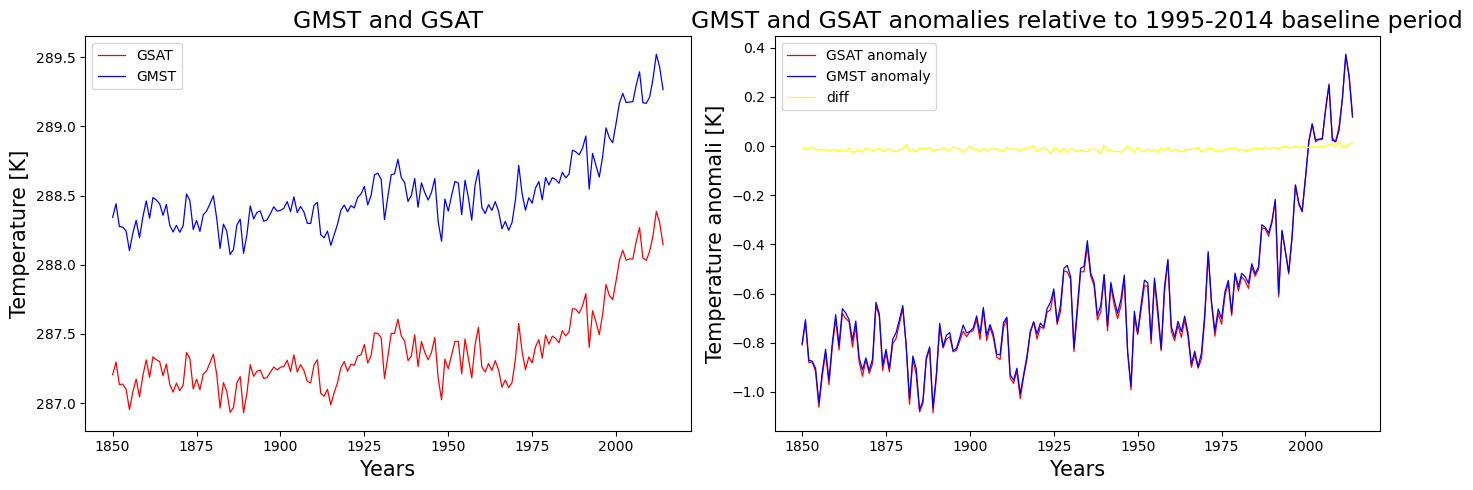

In [13]:
# calculate baseline GSAT AND GST (temporal mean for the climatological period used as baseline)
GSAT_baseline = tas_w_sm.sel(time=slice('1995','2014')).mean()
GMST_baseline = ts_w_sm.sel(time=slice('1995','2014')).mean()

fig, (axs) = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

GSAT = tas_w_sm.groupby('time.year').mean('time')
GSAT.plot(ax=axs[0], linewidth = 0.9, color='red', label='GSAT')
GMST = ts_w_sm.groupby('time.year').mean('time')
GMST.plot(ax=axs[0], linewidth = 0.9, color='blue', label='GMST')

GSAT_anomaly = (tas_w_sm - GSAT_baseline).groupby('time.year').mean('time')
GSAT_anomaly.plot(ax=axs[1], linewidth = 0.9, color='red', label='GSAT anomaly')
GMST_anomaly = (ts_w_sm - GMST_baseline).groupby('time.year').mean('time')
GMST_anomaly.plot(ax=axs[1], linewidth = 0.9, color='blue', label='GMST anomaly')
diff_GSAT_GMST = ( (tas_w_sm - GSAT_baseline).groupby('time.year').mean('time')-(ts_w_sm - GMST_baseline).groupby('time.year').mean('time') ).plot(ax=axs[1], linewidth = 0.9, color='yellow', label='diff')

axs[0].set_ylabel('Temperature [K]', fontsize=15)
axs[0].set_xlabel('Years', fontsize=15)
axs[1].set_xlabel('Years', fontsize=15)
axs[1].set_ylabel('Temperature anomali [K]', fontsize=15)
axs[0].set_title('GMST and GSAT', fontsize=17)
axs[1].set_title('GMST and GSAT anomalies relative to 1995-2014 baseline period', fontsize=17)
axs[0].legend()
axs[1].legend()
plt.tight_layout()


### Extension: use more ensemble members, more models etc.

...